In [1]:
# importing packages
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import conductivity as cd
from matplotlib.ticker import MaxNLocator

# Mean spherical approximation (MSA) model constants

In [2]:
# temperature in K
temp = 298.15

# diffusion coefficients at infinite dilution in m^2/s
Diff_Na = 1.334 * 10**(-9)
Diff_Cl = 2.032 * 10**(-9)
Diff_Ca = 0.792 * 10**(-9)
Diff_La = 0.619 * 10**(-9)
Diff_Cu = 0.714 * 10**(-9)
Diff_Al = 0.541 * 10**(-9)
diffusion_coeff = [Diff_La, Diff_Ca, Diff_Na, Diff_Cl] 

# valencies
z_Na = 1
z_Cl = -1
z_Ca = 2
z_La = 3
z_Cu = 2
z_Al = 3
valency = [z_La, z_Ca, z_Na, z_Cl]

# hard sphere diameters in m
sigma_Cl = 2 * 181 * 10**(-12)
sigma_Ca = 2 * 100 * 10**(-12)
sigma_La = 2 * 118 * 10**(-12)
sigma_Na = 2 * 102 * 10**(-12)
sigma_Cu = 2 * 73 * 10**(-12)
sigma_Al = 2 * 53 * 10**(-12)
diameter = [sigma_La, sigma_Ca, sigma_Na, sigma_Cl]

# solvent viscosity in Pa.s
eta_msa = 0.89 * 10**(-3)

# relative permittivity
epsilon = 78.43

# limiting molar conductivity of ions in m^2.S/mol
lambda_0_Na_mol = 50.08 * 10**(-4)
lambda_0_Cl_mol = 76.31 * 10**(-4)
lambda_0_Ca_mol = 59.47 * 10**(-4)
lambda_0_La_mol = 69.7 * 10**(-4)
lambda_0_Cu_mol = 53.6 * 10**(-4)
lambda_0_Al_mol = 61.0 * 10**(-4)
lambda_0_La_Ca_Na_Cl = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Na_mol, lambda_0_Cl_mol]

# Shedlovsky model constants

In [3]:
# solvent viscosity in poise
eta_shed = 8.903*10**(-3)

# limiting equivalent conductivity of salts in cm^2.Siemen.equiv^(-1)
lambda_0_NaCl = 126.45 
lambda_0_CaCl2 = 135.85
lambda_0_LaCl3 = 145.9

# limiting equivalent conductivity of ions in cm^2.Siemen.equiv^(-1)
lambda_0_Na = 50.10 
lambda_0_Ca = 59.5
lambda_0_La = 69.7
lambda_0_Cl = 76.35

# distance of closest approach of ions in cm
a_NaCl = 4*10**(-8)
a_CaCl2 = 4.31*10**(-8)
a_LaCl3 = 4.9*10**(-8)
a_Na_Ca_La = (a_NaCl + a_CaCl2 + a_LaCl3)/3

# Determine the concentrations to discriminate between the MSA and Shedlovsky models in ternary systems

In [4]:
def three_salts_conc(LaCl3_conc, NaCl_conc, ionic_strength, fig_name):
    """
    Calculates the concentration of CaCl2 from NaCl and LaCl3 concentrations 
    and computes the difference in conductivity predictions between the 
    Shedlovsky and MSA models

    Arguments:
        LaCl3_conc: pandas.Series or list or numpy.ndarray
            Concentration of LaCl3 in mM
        NaCl_conc: pandas.Series or list or numpy.ndarray
            Concentration of NaCl in mM
        ionic_strength: int or float
            Desired ionic strength of the ternary salt solution
        fig_name: str 
            Name of figure to save on the GitHub repository
    """
    na_conc_plot = []
    la_conc_plot = []
    ca_conc_plot = []
    
    # save the results
    residuals_percent = []
    
    for conc_na in NaCl_conc:
        for conc_la in LaCl3_conc:
            conc_ca = (2 * ionic_strength - conc_na * z_Na * (z_Na + z_Cl**2) 
                       - conc_la * z_La * (z_La + z_Cl**2)) / (z_Ca * (z_Ca + z_Cl**2))
            conc_list = [conc_na, conc_ca, conc_la]
            
            print("The concentration of NaCl is:",conc_na)
            print("The concentration of LaCl3 is:",conc_la)
            print("The concentration of CaCl2 is:",conc_ca)

            if all(conc_species >= 1 for conc_species in conc_list):
                # append the species concentration to their respective list
                na_conc_plot.append(conc_na)
                la_conc_plot.append(conc_la)
                ca_conc_plot.append(conc_ca)

                # calculate the species ionic strength
                ionic_str_na = 0.5 * conc_na * z_Na**2
                ionic_str_la = 0.5 * conc_la * z_La**2
                ionic_str_ca = 0.5 * conc_ca * z_Ca**2
                ionic_str_cl = 0.5 * (z_Na * conc_na + z_Ca * conc_ca + z_La * conc_la) * z_Cl**2
                # print("The ionic strength of Na+ is:",ionic_str_na)
                # print("The ionic strength of La3+ is:",ionic_str_la)
                # print("The ionic strength of Ca2+ is:",ionic_str_ca)
                # print("The ionic strength of Cl- is:",ionic_str_cl)
                
                # evaluate the salt concentrations in M
                conc_NaCl_shed = [conc_na * 10**(-3)]
                conc_CaCl2_shed = [conc_ca * 10**(-3)]
                conc_LaCl3_shed = [conc_la * 10**(-3)]
        
                # calculate the individual salt conductivity using the Shedlovsky model
                shed_cond_NaCl = cd.shedlovsky(conc_NaCl_shed, temp, epsilon, eta_shed, lambda_0_NaCl, 
                                               a_Na_Ca_La, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
                shed_cond_CaCl2 = cd.shedlovsky(conc_CaCl2_shed, temp, epsilon, eta_shed, lambda_0_CaCl2, 
                                                a_Na_Ca_La, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
                shed_cond_LaCl3 = cd.shedlovsky(conc_LaCl3_shed, temp, epsilon, eta_shed, lambda_0_LaCl3, 
                                                a_Na_Ca_La, z_La, z_Cl, lambda_0_La, lambda_0_Cl)
            
                # get the number of data
                ndata_all = len(shed_cond_NaCl)
            
                # calculate the bulk conductivity using the Shedlovsky model
                shed_cond = [shed_cond_NaCl[i] + shed_cond_CaCl2[i] + shed_cond_LaCl3[i] 
                             for i in range(ndata_all)]
            
                # calculate the bulk conductivity using the MSA model
                msa_cond = cd.msa(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, 
                                  lambda_0_La_Ca_Na_Cl, [conc_la], [conc_ca], [conc_na])
            
                # compute the percent difference between the predictions of the MSA and Shedlovksy models
                residuals = [shed_cond[i] - msa_cond[i] for i in range(ndata_all)]
                residuals_per = [100 * residuals[i] / msa_cond[i] for i in range(ndata_all)]
                print(f"The percent difference between the models for {(conc_na, conc_la)} is:", 
                      residuals_per)
                
                residuals_percent.append(residuals_per)
            else:
                na_conc_plot.append(conc_na)
                la_conc_plot.append(conc_la)
                ca_conc_plot.append(np.nan)
                residuals_percent.append([np.nan])

    residuals_percent_array = np.asarray(residuals_percent)
    
    # plot the model difference results
    # X and Y axis labels
    x_label = "Concentration of Na$\mathbf{^{+}} (mM)$"
    y_label = "Concentration of La$\mathbf{^{3+}} (mM)$"
    data_res = np.zeros((len(residuals_percent_array), 3))
    data_res[:, 0] = na_conc_plot
    data_res[:, 1] = la_conc_plot
    data_res[:, 2] = residuals_percent_array[:, 0]

    plot_heatmap(data_res, y_label, x_label, "Model Prediction Difference (%)", fig_name)

    # plot the salt concentration results
    data_conc = np.zeros((len(ca_conc_plot), 3))
    data_conc[:, 0] = na_conc_plot
    data_conc[:, 1] = la_conc_plot
    data_conc[:, 2] = ca_conc_plot
    
    plot_heatmap(data_conc, y_label, x_label, "Concentration of Ca$\mathbf{^{2+}} (mM)$", 
                 f"{fig_name}_conc")

In [5]:
# Make the heat map plot
def plot_heatmap(data, y_label, x_label, colorbar_label, figure_name):
    """
    Arguments:
        data: numpy.ndarray,
            Matrix containing the concentration of NaCl and LaCl3 and 
            the model prediction difference or CaCl2 concentration
        y_label: str
            Y-axis label for the heat map plot
        x_label: str
            X-axis label for the heat map plot
        colorbar_label: str
            Colorbar label for the heat map plot
        figure_name: str
            Name of figure to save on the GitHub repository
    """
    # set the heatmap x,y ranges
    x_tick_labels_0 = np.sort(np.unique(data[:, 0]))
    y_tick_labels_0 = np.sort(np.unique(data[:, 1]))[::-1]

    x_tick_labels = [int(x) for x in x_tick_labels_0]
    y_tick_labels = [int(y) for y in y_tick_labels_0]

    # reshape values
    opt_vals = data[:, 2].reshape(len(x_tick_labels), len(y_tick_labels))

    # create the figure
    fig, ax = plt.subplots()

    params = {"mathtext.default": "regular"}
    plt.rcParams.update(params)

    # colormap with solid gray for NaN entries
    cmap = plt.cm.hot_r.copy()
    cmap.set_bad(color='lightgray')

    # plot the heatmap
    im = ax.imshow(opt_vals.T, cmap=cmap)

    # set the ticks and labels
    ax.set_yticks(range(len(y_tick_labels)))
    ax.set_yticklabels(y_tick_labels)
    ax.set_ylabel(y_label, fontsize=16.5, fontweight='bold')

    ax.set_xticks(range(len(x_tick_labels)))
    ax.set_xticklabels(x_tick_labels)
    ax.set_xlabel(x_label, fontsize=16.5, fontweight='bold')

    ax.xaxis.set_major_locator(MaxNLocator(nbins=9))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=9))

    plt.xticks(fontsize=16.5)
    plt.yticks(fontsize=16.5)

    # set colorbar
    cbar = plt.colorbar(im)
    cbar.set_label(colorbar_label, fontsize=16.5, fontweight='bold')
    cbar.ax.tick_params(labelsize=16.5)

    plt.tight_layout()
    plt.savefig(f"Ternary_salts/{figure_name}_three_salts_heat.png")
    plt.show()

## Model discrimination for 50 mM Ionic Strength

The concentration of NaCl is: 1
The concentration of LaCl3 is: 9
The concentration of CaCl2 is: -1.6666666666666667
The concentration of NaCl is: 1
The concentration of LaCl3 is: 8
The concentration of CaCl2 is: 0.3333333333333333
The concentration of NaCl is: 1
The concentration of LaCl3 is: 7
The concentration of CaCl2 is: 2.3333333333333335
Relaxation correction: [-0.09547004 -0.03787809 -0.00984675 -0.08218058]
Hydrodynamic correction: [-0.24638383 -0.1947205  -0.11546729 -0.07221905]
Relative ionic strength: [0.63       0.09333333 0.01       0.26666667]
Transport number: [0.38266242 0.07253483 0.01309002 0.53171273]
Ionic mobility: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 247506659560.32922
Alpha: [np.float64(0.0), np.float64(185817594865.0874), np.float64(315583157007.59534), np.float64(363032203089.4484)]
zeta matrix: [[ 1.44468591 -0.56170106 -0.26102938 -0.37750181]
 [ 1.12911689  3.4688991  -0.4108092  -0.55637285]
 [ 0.67036025  0.20497

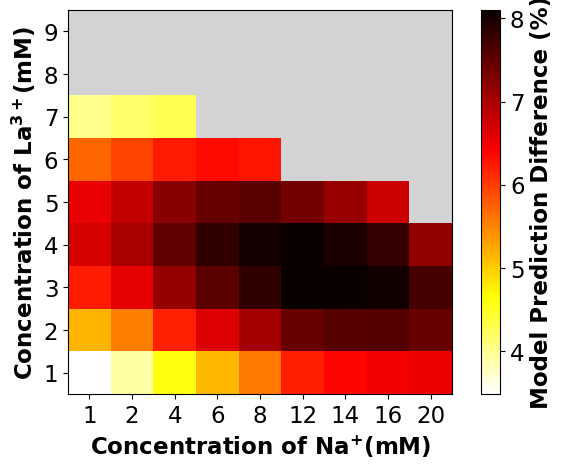

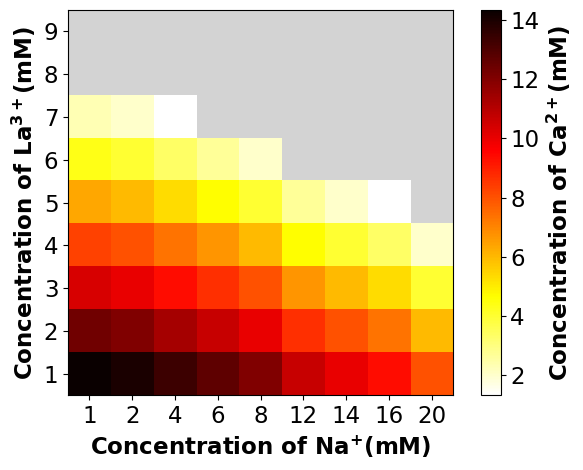

In [6]:
# desired ionic strength in mM
ionic_strength_50 = 50

# cation concentration in mM
na_50 = [1, 2, 4, 6, 8, 12, 14, 16, 20]
la_50 = [9, 8, 7, 6, 5, 4, 3, 2, 1]

three_salts_conc(la_50, na_50, ionic_strength_50, "ionic_str_50")

## Model discrimination for 100 mM Ionic Strength

The concentration of NaCl is: 4
The concentration of LaCl3 is: 16
The concentration of CaCl2 is: 0.0
The concentration of NaCl is: 4
The concentration of LaCl3 is: 14
The concentration of CaCl2 is: 4.0
Relaxation correction: [-0.12043329 -0.0484649  -0.01285613 -0.10180263]
Hydrodynamic correction: [-0.32737806 -0.25973342 -0.15395153 -0.09481732]
Relative ionic strength: [0.63 0.08 0.02 0.27]
Transport number: [0.37910854 0.06159529 0.02593691 0.53335926]
Ionic mobility: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 249826864991.60953
Alpha: [np.float64(0.0), np.float64(186572897565.0412), np.float64(308668402700.6422), np.float64(366828591025.05505)]
zeta matrix: [[ 1.45584564 -0.5317497  -0.33920814 -0.34707432]
 [ 1.13783895  3.79310969 -0.5412421  -0.5096123 ]
 [ 0.67553857  0.1994168   5.48198382 -2.82963451]
 [ 0.44348841  0.10209333  0.54578081  1.17043887]]
The percent difference between the models for (4, 14) is: [np.float64(5.301159770140139

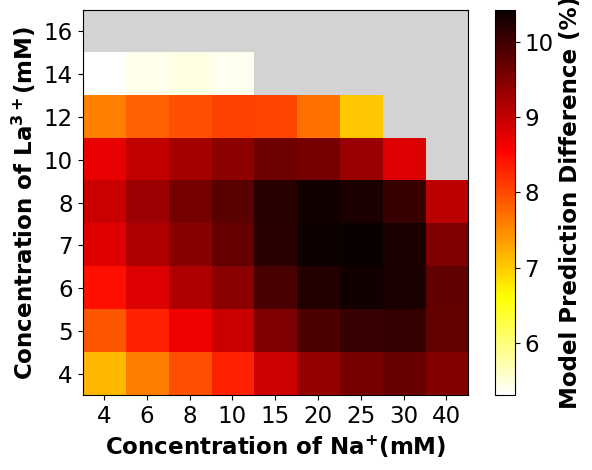

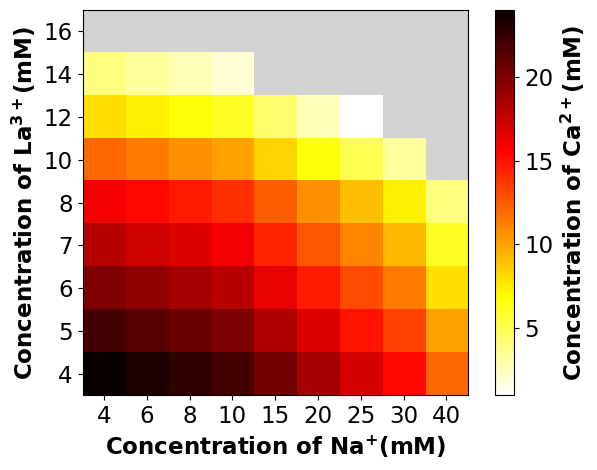

In [7]:
# data in mM
ionic_strength_100 = 100

# cation concentration in mM
na_100 = [4, 6, 8, 10, 15, 20, 25, 30, 40]
la_100 = [16, 14, 12, 10, 8, 7, 6, 5, 4]

three_salts_conc(la_100, na_100, ionic_strength_100, "ionic_str_100")

## Model discrimination for 150 mM Ionic Strength

The concentration of NaCl is: 8
The concentration of LaCl3 is: 24
The concentration of CaCl2 is: -0.6666666666666666
The concentration of NaCl is: 8
The concentration of LaCl3 is: 20
The concentration of CaCl2 is: 7.333333333333333
Relaxation correction: [-0.13825022 -0.05705681 -0.01567653 -0.11198297]
Hydrodynamic correction: [-0.38330317 -0.30492643 -0.18068274 -0.11012006]
Relative ionic strength: [0.6        0.09777778 0.02666667 0.27555556]
Transport number: [0.35563055 0.07415194 0.03406291 0.5361546 ]
Ionic mobility: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 253638014247.945
Alpha: [np.float64(0.0), np.float64(185177783333.7266), np.float64(304812137765.0222), np.float64(368754461556.65955)]
zeta matrix: [[ 1.47761339 -0.61553375 -0.37304143 -0.33245131]
 [ 1.15485188  3.39918756 -0.60021643 -0.48724275]
 [ 0.68563919  0.21940933  4.68810217 -2.6193325 ]
 [ 0.45011943  0.11287862  0.57156034  1.1502623 ]]
The percent difference between the 

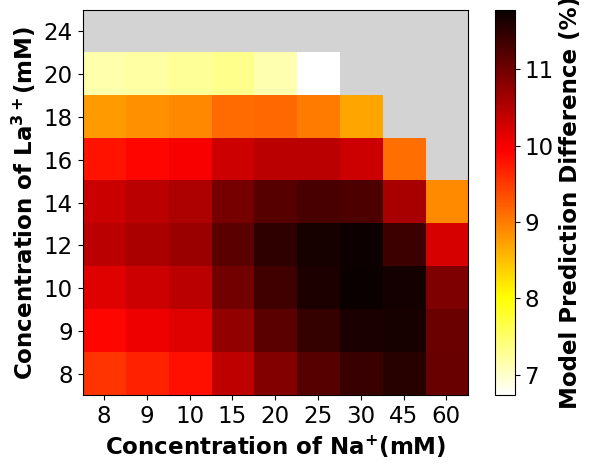

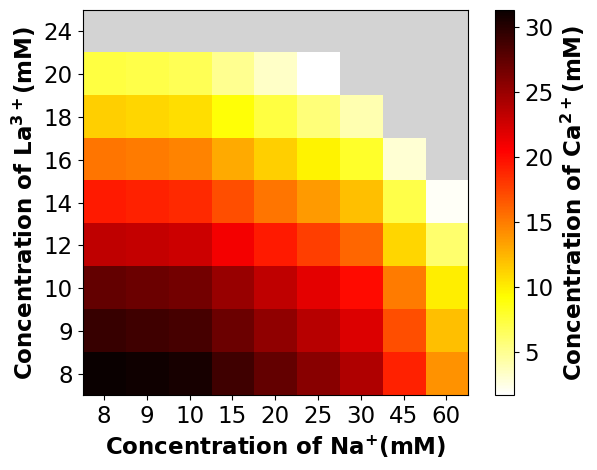

In [8]:
# desired ionic strength in mM
ionic_strength_150 = 150

# cation concentration in mM
na_150 = [8, 9, 10, 15, 20, 25, 30, 45, 60]
la_150 = [24, 20, 18, 16, 14, 12, 10, 9, 8]

three_salts_conc(la_150, na_150, ionic_strength_150, "ionic_str_150")

## Model discrimination for 200 mM Ionic Strength

The concentration of NaCl is: 12
The concentration of LaCl3 is: 32
The concentration of CaCl2 is: -1.3333333333333333
The concentration of NaCl is: 12
The concentration of LaCl3 is: 28
The concentration of CaCl2 is: 6.666666666666667
Relaxation correction: [-0.1456693  -0.05954095 -0.0161334  -0.12094849]
Hydrodynamic correction: [-0.42656354 -0.34006395 -0.20145394 -0.12179248]
Relative ionic strength: [0.63       0.06666667 0.03       0.27333333]
Transport number: [0.37562006 0.05085709 0.03854736 0.53497549]
Ionic mobility: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 252147070422.88983
Alpha: [np.float64(0.0), np.float64(187375116923.01044), np.float64(302510733605.27264), np.float64(369845227275.8924)]
zeta matrix: [[ 1.4670554  -0.49693421 -0.39561194 -0.32643631]
 [ 1.14660012  4.20837116 -0.63987413 -0.47793659]
 [ 0.6807401   0.19175945  4.36671127 -2.52463189]
 [ 0.44690319  0.09789399  0.58863095  1.14605952]]
The percent difference between

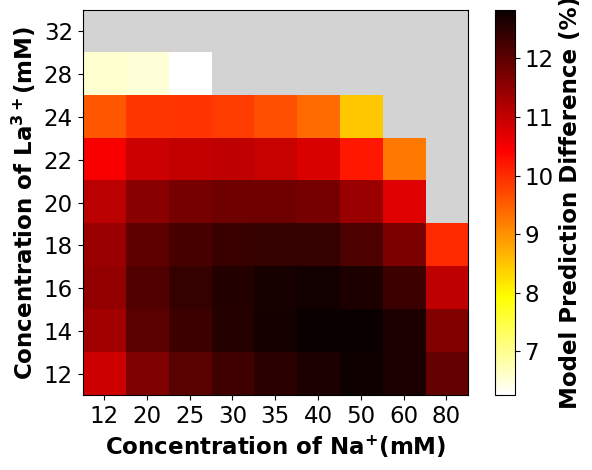

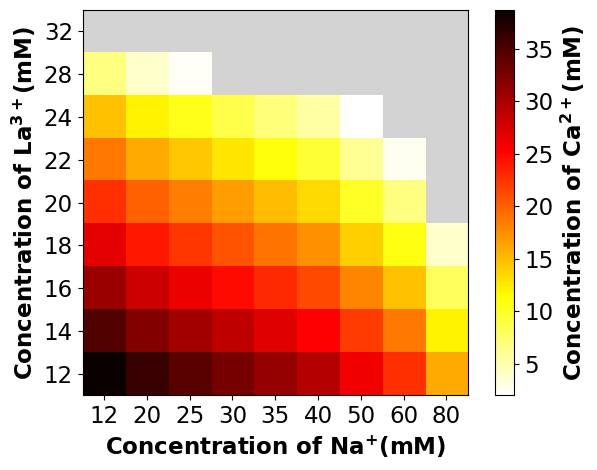

In [9]:
# desired ionic strength in mM
ionic_strength_200 = 200

# cation concentration in mM
na_200 = [12, 20, 25, 30, 35, 40, 50, 60, 80]
la_200 = [32, 28, 24, 22, 20, 18, 16, 14, 12]

three_salts_conc(la_200, na_200, ionic_strength_200, "ionic_str_200")

## Experimental validation of the optimal experimental conditions

### Load the ternary salt solution data

In [10]:
three_salts = pd.read_csv("./Data/Na_Ca_La_cond.csv")
NaCl_conc_three_salts = three_salts["NaCl Conc"]
CaCl2_conc_three_salts = three_salts["CaCl2 Conc"]
LaCl3_conc_three_salts = three_salts["LaCl3 Conc"]
three_salts_cond_raw = three_salts["Cond"]

# get the number of data
ndata_three_salts = len(NaCl_conc_three_salts)

# convert the conductivity from micro.S/cm to milli.S/cm
three_salts_cond = [three_salts_cond_raw[i] * 10**(-3) for i in range(ndata_three_salts)]

# measurement error in %
sigma_cond = 0.93

# measurement error in milli.S/cm
error_na_ca_la = [(sigma_cond/100) * three_salts_cond[i] for i in range(ndata_three_salts)]

In [11]:
# evaluate the salts concentration in M
conc_NaCl_shed_three = [NaCl_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]
conc_CaCl2_shed_three = [CaCl2_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]
conc_LaCl3_shed_three = [LaCl3_conc_three_salts[i] * 10**(-3) for i in range(ndata_three_salts)]

# calculate the individual salt conductivity using the Shedlovsky model
shed_cond_NaCl_3 = cd.shedlovsky(conc_NaCl_shed_three, temp, epsilon, eta_shed, lambda_0_NaCl, 
                                 a_Na_Ca_La, z_Na, z_Cl, lambda_0_Na, lambda_0_Cl)
shed_cond_CaCl2_3 = cd.shedlovsky(conc_CaCl2_shed_three, temp, epsilon, eta_shed, lambda_0_CaCl2, 
                                  a_Na_Ca_La, z_Ca, z_Cl, lambda_0_Ca, lambda_0_Cl)
shed_cond_LaCl3_3 = cd.shedlovsky(conc_LaCl3_shed_three, temp, epsilon, eta_shed, lambda_0_LaCl3, 
                                  a_Na_Ca_La, z_La, z_Cl, lambda_0_La, lambda_0_Cl)

# calculate the bulk conductivity using the Shedlovsky model
shed_cond_3 = [shed_cond_NaCl_3[i] + shed_cond_CaCl2_3[i] + shed_cond_LaCl3_3[i] 
               for i in range(ndata_three_salts)]

# calculate the bulk conductivity using the MSA transport model
msa_cond_3 = cd.msa(valency, diameter, diffusion_coeff, temp, eta_msa, epsilon, lambda_0_La_Ca_Na_Cl, 
                    LaCl3_conc_three_salts, CaCl2_conc_three_salts, NaCl_conc_three_salts)

Relaxation correction: [-0.18717426 -0.09126877 -0.03053849 -0.09855933]
Hydrodynamic correction: [-0.42685723 -0.34029852 -0.20159288 -0.12187565]
Relative ionic strength: [0.315 0.22  0.125 0.34 ]
Transport number: [0.15893076 0.14202167 0.13591663 0.56313093]
Ionic mobility: [1.50335711e+11 1.92351992e+11 3.23986816e+11 4.93509152e+11]
Average mobility: 297964651192.6128
Alpha: [np.float64(0.0), np.float64(171591196387.97342), np.float64(267580927289.7749), np.float64(383159251460.30835)]
zeta matrix: [[ 1.74819456 -1.66435744 -0.63511193 -0.24982198]
 [ 1.36632883  1.92855413 -1.15077439 -0.36155442]
 [ 0.81119373  0.3249792   2.0098855  -1.59817546]
 [ 0.53254549  0.1746126   0.59410276  1.0529642 ]]


In [12]:
# calculate the ionic strength of the experimental conditions for plotting
def ionic_strength(salt_1_conc, salt_2_conc, salt_3_conc, valency, salt_4_conc=None):
    """ 
    Calculates the ionic strength of the salt solution

    Arguments:
        salt_conc_1: pandas.Series or list or numpy.ndarray
            Concentration of the highest-valence salt in mM
        salt_conc_2: pandas.Series or list or numpy.ndarray
            Concentration of the second highest-valence salt in mM
        salt_conc_3: pandas.Series or list or numpy.ndarray
            Concentration of the third highest-valence salt in mM
        valency: list
            Valency of ions in decreasing order
        salt_conc_3: pandas.Series or list or numpy.ndarray
            Concentration of the lowest-valence salt in mM

    Returns:
        ionic_strength: list
            Ionic strength of the salt solution
    """
    # number of datapoints
    ndata = len(salt_1_conc)
    
    # calculate the species concentration
    cation_1_conc = salt_1_conc
    cation_2_conc = salt_2_conc
    cation_3_conc = salt_3_conc

    # get the number of ions
    n_species = len(valency)
    
    if salt_4_conc is None:
        anion_conc = [valency[0] * salt_1_conc[i] + valency[1] * salt_2_conc[i] 
                      + valency[2] * salt_3_conc[i] for i in range(ndata)]
    else:
        cation_4_conc = salt_4_conc
        anion_conc = [valency[0] * salt_1_conc[i] 
                      + valency[1] * salt_2_conc[i] 
                      + valency[2] * salt_3_conc[i] 
                      + valency[3] * salt_4_conc[i] for i in range(ndata)]
    
    
    # calculate the ionic stength of the solution
    ionic_strength = []
    for i in range(ndata):
        if salt_4_conc is None:
            ion_conc = [cation_1_conc[i], cation_2_conc[i], cation_3_conc[i], anion_conc[i]]
        else:
            ion_conc = [cation_1_conc[i], cation_2_conc[i], cation_3_conc[i], 
                        cation_4_conc[i], anion_conc[i]]
        # update the ionic strength container
        ionic_strength.append(0.5 * sum(ion_conc[j] * valency[j] ** 2 for j in range(n_species)))

    return ionic_strength

# calculate the ionic strengths
ionic_strength_na_ca_la = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                         NaCl_conc_three_salts, valency)
print(ionic_strength_na_ca_la)

[np.float64(50.0), np.float64(100.0), np.float64(150.0), np.float64(200.0)]


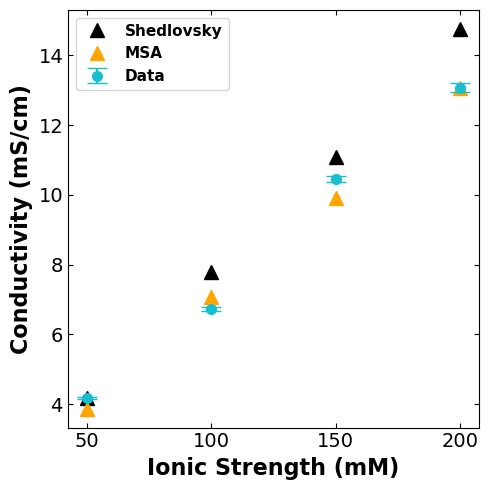

In [13]:
# plot comparing the model predictions and the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_la, shed_cond_3, "^", color="black", linewidth=3, 
         markersize=10, label="Shedlovsky")
plt.plot(ionic_strength_na_ca_la, msa_cond_3, "^", linewidth=3, markersize=10, 
         color="orange", label="MSA")
plt.errorbar(
    ionic_strength_na_ca_la, three_salts_cond, yerr=error_na_ca_la, fmt='o', ecolor='tab:cyan', 
    capsize=7, markersize=7, markerfacecolor='tab:cyan', markeredgecolor='tab:cyan', label='Data')
plt.xlabel("Ionic Strength (mM)", fontsize=16,fontweight='bold')
plt.ylabel("Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks([50, 100, 150, 200], fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Ternary_salts\shed_msa_na_ca_la.png")
plt.show()

The mean absolute percent error for the Shedlovsky model is: 8.77301147437318
The mean absolute percent error for the MSA model is: 4.3768188940773305

The mean absolute error for the Shedlovsky model is: 0.8497227093729542
The mean absolute error for the MSA model is: 0.2950503597185806

The mean squared error for the Shedlovsky model is: 1.0956262513361295
The mean squared error for the MSA model is: 0.12337457347255187


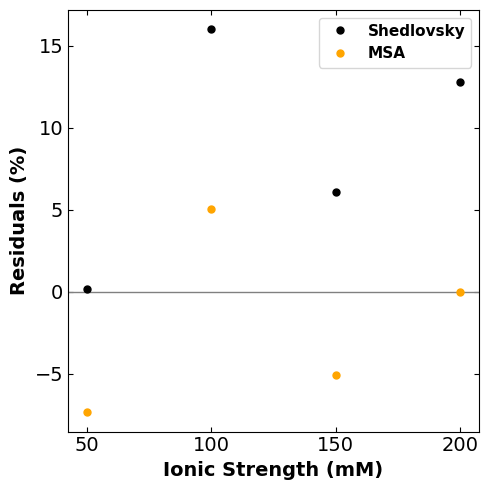

In [14]:
# calculate the prediction residuals
e_three_salts_shed = [shed_cond_3[i] - three_salts_cond[i] for i in range(ndata_three_salts)]
e_three_salts_msa = [msa_cond_3[i] - three_salts_cond[i] for i in range(ndata_three_salts)]

# percent prediction residuals
residuals_percent_shed_3 = [100*e_three_salts_shed[i]/three_salts_cond[i] 
                            for i in range(ndata_three_salts)]
residuals_percent_msa_3 = [100*e_three_salts_msa[i]/three_salts_cond[i] 
                           for i in range(ndata_three_salts)]

# calculate the mean absolute percent error
residuals_percent_shed_3_abs = [np.abs(residuals_percent_shed_3[i]) 
                                for i in range(ndata_three_salts)]
residuals_percent_msa_3_abs = [np.abs(residuals_percent_msa_3[i]) 
                               for i in range(ndata_three_salts)]
print("The mean absolute percent error for the Shedlovsky model is:",
      np.mean(residuals_percent_shed_3_abs))
print("The mean absolute percent error for the MSA model is:",
      np.mean(residuals_percent_msa_3_abs))

# calculate the mean absolute error
residuals_abs_shed_3 = [np.abs(e_three_salts_shed[i]) for i in range(ndata_three_salts)]
residuals_abs_msa_3 = [np.abs(e_three_salts_msa[i]) for i in range(ndata_three_salts)]
print("\nThe mean absolute error for the Shedlovsky model is:",np.mean(residuals_abs_shed_3))
print("The mean absolute error for the MSA model is:",np.mean(residuals_abs_msa_3))

# calculate the mean squared error
sq_residuals_shed_3 = [e_three_salts_shed[i]**2 for i in range(ndata_three_salts)]
sq_residuals_msa_3 = [e_three_salts_msa[i]**2 for i in range(ndata_three_salts)]
print("\nThe mean squared error for the Shedlovsky model is:",np.mean(sq_residuals_shed_3))
print("The mean squared error for the MSA model is:",np.mean(sq_residuals_msa_3))

# plot the prediction residuals of the Shedlovsky and MSA models
fig = plt.figure(figsize=(5, 5))
plt.axhline(0, color="0.5", lw=1)
plt.plot(ionic_strength_na_ca_la, residuals_percent_shed_3, ".", color="black", markersize=10, 
         label="Shedlovsky")
plt.plot(ionic_strength_na_ca_la, residuals_percent_msa_3, ".", markersize=10, color="orange", 
         label="MSA")
plt.xlabel("Ionic Strength (mM)", fontsize=14,fontweight='bold')
plt.ylabel("Residuals (%)", fontsize=14,fontweight='bold')
plt.xticks([50, 100, 150, 200], fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Ternary_salts\shed_msa_na_ca_la_resid.png")
plt.show()

# Evaluate the robustness of the MSA model to uncharacterized impurities

In [15]:
# load the concentrations of the impurity
ternary_impurity = pd.read_csv("./Data/ternary_impurity.csv")
CuCl2_conc_0_5_per = ternary_impurity["CuCl2_conc_0_5"]
CuCl2_conc_1_per = ternary_impurity["CuCl2_conc_1"]
CuCl2_conc_2_per = ternary_impurity["CuCl2_conc_2"]
CuCl2_conc_5_per = ternary_impurity["CuCl2_conc_5"]
CuCl2_conc_10_per = ternary_impurity["CuCl2_conc_10"]

AlCl3_conc_0_5_per = ternary_impurity["AlCl3_conc_0_5"]
AlCl3_conc_1_per = ternary_impurity["AlCl3_conc_1"]
AlCl3_conc_2_per = ternary_impurity["AlCl3_conc_2"]
AlCl3_conc_5_per = ternary_impurity["AlCl3_conc_5"]
AlCl3_conc_10_per = ternary_impurity["AlCl3_conc_10"]

## Divalent impurity (CuCl2)

In [16]:
valency_imp = [z_La, z_Ca, z_Cu, z_Na, z_Cl]

diffusion_coeff_imp = [Diff_La, Diff_Ca, Diff_Cu, Diff_Na, Diff_Cl] 

diameter_imp = [sigma_La, sigma_Ca, sigma_Cu, sigma_Na, sigma_Cl]

lambda_0_imp = [lambda_0_La_mol, lambda_0_Ca_mol, lambda_0_Cu_mol, 
                lambda_0_Na_mol, lambda_0_Cl_mol]

# calculate the bulk conductivity using the MSA transport model
msa_cond_imp_0_5 = cd.msa(valency_imp, diameter_imp, diffusion_coeff_imp, temp, eta_msa, 
                          epsilon, lambda_0_imp, LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                          CuCl2_conc_0_5_per, NaCl_conc_three_salts,)

msa_cond_imp_1 = cd.msa(valency_imp, diameter_imp, diffusion_coeff_imp, temp, eta_msa, 
                        epsilon, lambda_0_imp, LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                        CuCl2_conc_1_per, NaCl_conc_three_salts,)

msa_cond_imp_2 = cd.msa(valency_imp, diameter_imp, diffusion_coeff_imp, temp, eta_msa, 
                        epsilon, lambda_0_imp, LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                        CuCl2_conc_2_per, NaCl_conc_three_salts,)

msa_cond_imp_5 = cd.msa(valency_imp, diameter_imp, diffusion_coeff_imp, temp, eta_msa, 
                        epsilon, lambda_0_imp, LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                        CuCl2_conc_5_per, NaCl_conc_three_salts,)

msa_cond_imp_10 = cd.msa(valency_imp, diameter_imp, diffusion_coeff_imp, temp, eta_msa, 
                         epsilon, lambda_0_imp, LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                         CuCl2_conc_10_per, NaCl_conc_three_salts,)

Relaxation correction: [-0.17505549 -0.185264    0.14676425 -0.03157021 -0.09819196]
Hydrodynamic correction: [-0.42770158 -0.34098467 -0.39057671 -0.20199846 -0.12210341]
Relative ionic strength: [0.31343284 0.21890547 0.00331675 0.12437811 0.33996683]
Transport number: [0.15818722 0.14135724 0.00193084 0.13528076 0.56324393]
Ionic mobility: [1.50335711e+11 1.92351992e+11 1.73408236e+11 3.23986816e+11
 4.93509152e+11]
Average mobility: 297875814824.8283
Alpha: [np.float64(0.0), np.float64(170603630500.656), np.float64(192351992488.29633), np.float64(267756028063.1322), np.float64(383062298984.68756)]
zeta matrix: [[ 1.74772622e+00 -1.50362484e+00 -1.45108013e-11 -6.33970843e-01
  -2.50114254e-01]
 [ 1.36596279e+00  1.58535331e+00  2.65975092e+00 -1.14779481e+00
  -3.62005827e-01]
 [ 1.51518561e+00  1.16932175e+01 -3.47818358e-11 -8.62501013e-01
  -3.06971419e-01]
 [ 8.10976408e-01  2.77851867e-01  6.62471418e-12  2.01577530e+00
  -1.60193227e+00]
 [ 5.32402819e-01  1.49722599e-01  3.3

In [17]:
# calculate the ionic strengths
ionic_strength_imp_0_5 = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                        CuCl2_conc_0_5_per, valency_imp, NaCl_conc_three_salts,)

ionic_strength_imp_1 = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                      CuCl2_conc_1_per, valency_imp, NaCl_conc_three_salts,)

ionic_strength_imp_2 = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                      CuCl2_conc_2_per, valency_imp, NaCl_conc_three_salts,)

ionic_strength_imp_5 = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                      CuCl2_conc_5_per, valency_imp, NaCl_conc_three_salts,)

ionic_strength_imp_10 = ionic_strength(LaCl3_conc_three_salts, CaCl2_conc_three_salts, 
                                       CuCl2_conc_10_per, valency_imp, NaCl_conc_three_salts,)

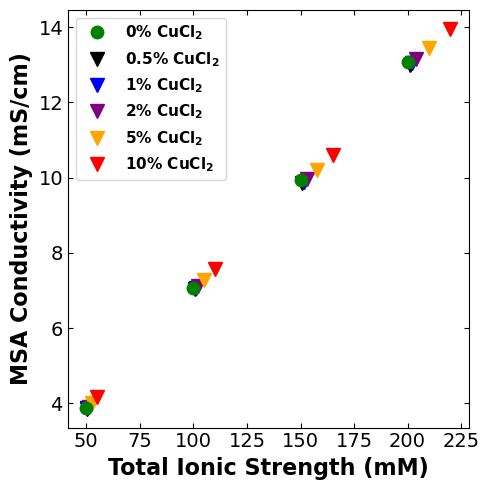

In [18]:
# plot comparing the model predictions and the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_la, msa_cond_3, ".", color="green", linewidth=3, 
         markersize=18, zorder=10, label="0% CuCl$_\mathbf{2}$")
plt.plot(ionic_strength_imp_0_5, msa_cond_imp_0_5, "v", color="black", linewidth=3, 
         markersize=10, label="0.5% CuCl$_\mathbf{2}$")
plt.plot(ionic_strength_imp_1, msa_cond_imp_1, "v", color="blue", linewidth=3, 
         markersize=10, label="1% CuCl$_\mathbf{2}$")
plt.plot(ionic_strength_imp_2, msa_cond_imp_2, "v", color="purple", linewidth=3, 
         markersize=10, label="2% CuCl$_\mathbf{2}$")
plt.plot(ionic_strength_imp_5, msa_cond_imp_5, "v", color="orange", linewidth=3, 
         markersize=10, label="5% CuCl$_\mathbf{2}$")
plt.plot(ionic_strength_imp_10, msa_cond_imp_10, "v", color="red", linewidth=3, 
         markersize=10, label="10% CuCl$_\mathbf{2}$")
plt.xlabel("Total Ionic Strength (mM)", fontsize=16,fontweight='bold')
plt.ylabel("MSA Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Ternary_salts\ternary_cucl2_imp.png")
plt.show()

In [19]:
# calculate the prediction residuals
e_imp_0_5 = [msa_cond_3[i] - msa_cond_imp_0_5[i] for i in range(ndata_three_salts)]
e_imp_1 = [msa_cond_3[i] - msa_cond_imp_1[i] for i in range(ndata_three_salts)]
e_imp_2 = [msa_cond_3[i] - msa_cond_imp_2[i] for i in range(ndata_three_salts)]
e_imp_5 = [msa_cond_3[i] - msa_cond_imp_5[i] for i in range(ndata_three_salts)]
e_imp_10 = [msa_cond_3[i] - msa_cond_imp_10[i] for i in range(ndata_three_salts)]

# percent prediction residuals
residuals_percent_0_5 = [100 * e_imp_0_5[i] / msa_cond_imp_0_5[i] 
                         for i in range(ndata_three_salts)]
residuals_percent_1 = [100 * e_imp_1[i] / msa_cond_imp_1[i] 
                       for i in range(ndata_three_salts)]
residuals_percent_2 = [100 * e_imp_2[i] / msa_cond_imp_2[i] 
                       for i in range(ndata_three_salts)]
residuals_percent_5 = [100 * e_imp_5[i] / msa_cond_imp_5[i] 
                       for i in range(ndata_three_salts)]
residuals_percent_10 = [100 * e_imp_10[i] / msa_cond_imp_10[i] 
                        for i in range(ndata_three_salts)]

# calculate the mean absolute percent error
residuals_percent_0_5_abs = [np.abs(residuals_percent_0_5[i]) 
                             for i in range(ndata_three_salts)]
residuals_percent_1_abs = [np.abs(residuals_percent_1[i]) 
                           for i in range(ndata_three_salts)]
residuals_percent_2_abs = [np.abs(residuals_percent_2[i]) 
                           for i in range(ndata_three_salts)]
residuals_percent_5_abs = [np.abs(residuals_percent_5[i]) 
                           for i in range(ndata_three_salts)]
residuals_percent_10_abs = [np.abs(residuals_percent_10[i]) 
                            for i in range(ndata_three_salts)]

print("The mean absolute percent error for +0.5% CuCl2 is:",
      np.mean(residuals_percent_0_5_abs))
print("The mean absolute percent error for +1% CuCl2 is:",
      np.mean(residuals_percent_1_abs))
print("The mean absolute percent error for +2% CuCl2 is:",
      np.mean(residuals_percent_2_abs))
print("The mean absolute percent error for +5% CuCl2 is:",
      np.mean(residuals_percent_5_abs))
print("The mean absolute percent error for +10% CuCl2 is:",
      np.mean(residuals_percent_10_abs))

The mean absolute percent error for +0.5% CuCl2 is: 0.5928650345111548
The mean absolute percent error for +1% CuCl2 is: 0.18121841273646222
The mean absolute percent error for +2% CuCl2 is: 0.6205372513304279
The mean absolute percent error for +5% CuCl2 is: 2.92885793692938
The mean absolute percent error for +10% CuCl2 is: 6.519597056809964


## Trivalent impurity (AlCl3)

In [20]:
valency_imp_tri = [z_La, z_Al, z_Ca, z_Na, z_Cl]

diffusion_coeff_imp_tri = [Diff_La, Diff_Al, Diff_Ca, Diff_Na, Diff_Cl] 

diameter_imp_tri = [sigma_La, sigma_Al, sigma_Ca, sigma_Na, sigma_Cl]

lambda_0_imp_tri = [lambda_0_La_mol, lambda_0_Al_mol, lambda_0_Ca_mol, 
                   lambda_0_Na_mol, lambda_0_Cl_mol]

# calculate the bulk conductivity using the MSA transport model
msa_cond_imp_0_5_tri = cd.msa(valency_imp_tri, diameter_imp_tri, diffusion_coeff_imp_tri, temp, eta_msa, 
                             epsilon, lambda_0_imp_tri, LaCl3_conc_three_salts, AlCl3_conc_0_5_per, 
                             CaCl2_conc_three_salts, NaCl_conc_three_salts,)

msa_cond_imp_1_tri = cd.msa(valency_imp_tri, diameter_imp_tri, diffusion_coeff_imp_tri, temp, eta_msa, 
                           epsilon, lambda_0_imp_tri, LaCl3_conc_three_salts, AlCl3_conc_1_per, 
                           CaCl2_conc_three_salts, NaCl_conc_three_salts,)

msa_cond_imp_2_tri = cd.msa(valency_imp_tri, diameter_imp_tri, diffusion_coeff_imp_tri, temp, eta_msa, 
                           epsilon, lambda_0_imp_tri, LaCl3_conc_three_salts, AlCl3_conc_2_per, 
                           CaCl2_conc_three_salts, NaCl_conc_three_salts,)

msa_cond_imp_5_tri = cd.msa(valency_imp_tri, diameter_imp_tri, diffusion_coeff_imp_tri, temp, eta_msa, 
                           epsilon, lambda_0_imp_tri, LaCl3_conc_three_salts, AlCl3_conc_5_per, 
                           CaCl2_conc_three_salts, NaCl_conc_three_salts,)

msa_cond_imp_10_tri = cd.msa(valency_imp_tri, diameter_imp_tri, diffusion_coeff_imp_tri, temp, eta_msa, 
                             epsilon, lambda_0_imp_tri, LaCl3_conc_three_salts, AlCl3_conc_10_per, 
                             CaCl2_conc_three_salts, NaCl_conc_three_salts,)

Relaxation correction: [-0.36093583 -0.13224778 -0.09138475 -0.03054408 -0.09887666]
Hydrodynamic correction: [-0.42776542 -0.52789182 -0.34103548 -0.20202856 -0.12212177]
Relative ionic strength: [0.31343284 0.00373134 0.21890547 0.12437811 0.33955224]
Transport number: [0.15834111 0.00164748 0.14149475 0.13541236 0.56310429]
Ionic mobility: [1.50335711e+11 1.31391954e+11 1.92351992e+11 3.23986816e+11
 4.93509152e+11]
Average mobility: 297586325832.4942
Alpha: [np.float64(0.0), np.float64(150335711300.91626), np.float64(171653191836.51105), np.float64(267686166739.70322), np.float64(383088928833.00916)]
zeta matrix: [[ 1.74517246e+00  2.51306176e+00 -1.66109055e+00 -6.34809194e-01
  -2.50071309e-01]
 [ 1.99678697e+00 -1.42889230e-11 -8.16737044e-01 -5.00378087e-01
  -2.09552097e-01]
 [ 1.36396686e+00  7.75366241e-12  1.93620738e+00 -1.14967647e+00
  -3.61935865e-01]
 [ 8.09791417e-01  2.28298137e-12  3.25441656e-01  2.01463809e+00
  -1.60113837e+00]
 [ 5.31624877e-01  1.29636303e-12  

In [21]:
# calculate the ionic strengths
ionic_strength_imp_0_5_tri = ionic_strength(LaCl3_conc_three_salts, AlCl3_conc_0_5_per, 
                                            CaCl2_conc_three_salts, valency_imp_tri, 
                                            NaCl_conc_three_salts,)

ionic_strength_imp_1_tri = ionic_strength(LaCl3_conc_three_salts, AlCl3_conc_1_per, 
                                          CaCl2_conc_three_salts, valency_imp_tri, 
                                          NaCl_conc_three_salts,)

ionic_strength_imp_2_tri = ionic_strength(LaCl3_conc_three_salts, AlCl3_conc_2_per, 
                                          CaCl2_conc_three_salts, valency_imp_tri, 
                                          NaCl_conc_three_salts,)

ionic_strength_imp_5_tri = ionic_strength(LaCl3_conc_three_salts, AlCl3_conc_5_per, 
                                          CaCl2_conc_three_salts, valency_imp_tri, 
                                          NaCl_conc_three_salts,)

ionic_strength_imp_10_tri = ionic_strength(LaCl3_conc_three_salts, AlCl3_conc_10_per, 
                                           CaCl2_conc_three_salts, valency_imp_tri, 
                                           NaCl_conc_three_salts,)

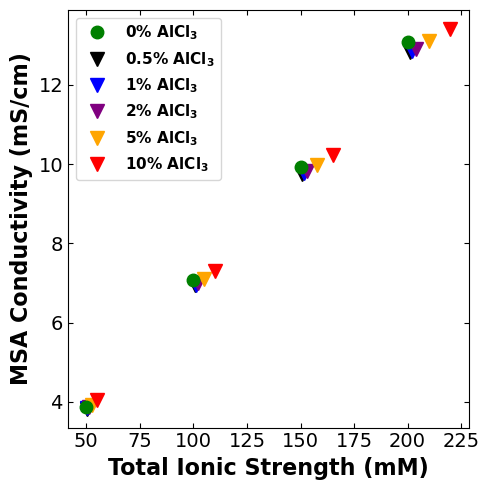

In [22]:
# plot comparing the model predictions and the data
fig = plt.figure(figsize=(5, 5))
plt.plot(ionic_strength_na_ca_la, msa_cond_3, ".", color="green", linewidth=3, 
         markersize=18, zorder=10, label="0% AlCl$_\mathbf{3}$")
plt.plot(ionic_strength_imp_0_5_tri, msa_cond_imp_0_5_tri, "v", color="black", linewidth=3, 
         markersize=10, label="0.5% AlCl$_\mathbf{3}$")
plt.plot(ionic_strength_imp_1_tri, msa_cond_imp_1_tri, "v", color="blue", linewidth=3, 
         markersize=10, label="1% AlCl$_\mathbf{3}$")
plt.plot(ionic_strength_imp_2_tri, msa_cond_imp_2_tri, "v", color="purple", linewidth=3, 
         markersize=10, label="2% AlCl$_\mathbf{3}$")
plt.plot(ionic_strength_imp_5_tri, msa_cond_imp_5_tri, "v", color="orange", linewidth=3, 
         markersize=10, label="5% AlCl$_\mathbf{3}$")
plt.plot(ionic_strength_imp_10_tri, msa_cond_imp_10_tri, "v", color="red", linewidth=3, 
         markersize=10, label="10% AlCl$_\mathbf{3}$")
plt.xlabel("Total Ionic Strength (mM)", fontsize=16,fontweight='bold')
plt.ylabel("MSA Conductivity (mS/cm)", fontsize=16,fontweight='bold')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(direction="in",top=True, right=True)
plt.legend(prop={"weight": "bold", "size": 11})
plt.tight_layout()
plt.savefig(r".\Ternary_salts\ternary_alcl3_imp.png")
plt.show()

In [23]:
# calculate the prediction residuals
e_imp_0_5_tri = [msa_cond_3[i] - msa_cond_imp_0_5_tri[i] for i in range(ndata_three_salts)]
e_imp_1_tri = [msa_cond_3[i] - msa_cond_imp_1_tri[i] for i in range(ndata_three_salts)]
e_imp_2_tri = [msa_cond_3[i] - msa_cond_imp_2_tri[i] for i in range(ndata_three_salts)]
e_imp_5_tri = [msa_cond_3[i] - msa_cond_imp_5_tri[i] for i in range(ndata_three_salts)]
e_imp_10_tri = [msa_cond_3[i] - msa_cond_imp_10_tri[i] for i in range(ndata_three_salts)]

# percent prediction residuals
residuals_percent_0_5_tri = [100 * e_imp_0_5_tri[i] / msa_cond_imp_0_5_tri[i] 
                             for i in range(ndata_three_salts)]
residuals_percent_1_tri = [100 * e_imp_1_tri[i] / msa_cond_imp_1_tri[i] 
                           for i in range(ndata_three_salts)]
residuals_percent_2_tri = [100 * e_imp_2_tri[i] / msa_cond_imp_2_tri[i] 
                           for i in range(ndata_three_salts)]
residuals_percent_5_tri = [100 * e_imp_5_tri[i] / msa_cond_imp_5_tri[i] 
                           for i in range(ndata_three_salts)]
residuals_percent_10_tri = [100 * e_imp_10_tri[i] / msa_cond_imp_10_tri[i] 
                            for i in range(ndata_three_salts)]

# calculate the mean absolute percent error
residuals_percent_0_5_abs_tri = [np.abs(residuals_percent_0_5_tri[i]) 
                                 for i in range(ndata_three_salts)]
residuals_percent_1_abs_tri = [np.abs(residuals_percent_1_tri[i]) 
                               for i in range(ndata_three_salts)]
residuals_percent_2_abs_tri = [np.abs(residuals_percent_2_tri[i]) 
                               for i in range(ndata_three_salts)]
residuals_percent_5_abs_tri = [np.abs(residuals_percent_5_tri[i]) 
                               for i in range(ndata_three_salts)]
residuals_percent_10_abs_tri = [np.abs(residuals_percent_10_tri[i]) 
                                for i in range(ndata_three_salts)]

print("The mean absolute percent error for +0.5% AlCl3 is:",
      np.mean(residuals_percent_0_5_abs_tri))
print("The mean absolute percent error for +1% AlCl3 is:",
      np.mean(residuals_percent_1_abs_tri))
print("The mean absolute percent error for +2% AlCl3 is:",
      np.mean(residuals_percent_2_abs_tri))
print("The mean absolute percent error for +5% AlCl3 is:",
      np.mean(residuals_percent_5_abs_tri))
print("The mean absolute percent error for +10% AlCl3 is:",
      np.mean(residuals_percent_10_abs_tri))

The mean absolute percent error for +0.5% AlCl3 is: 1.7251678433518403
The mean absolute percent error for +1% AlCl3 is: 1.452012129755082
The mean absolute percent error for +2% AlCl3 is: 0.9111708188798262
The mean absolute percent error for +5% AlCl3 is: 0.6689252969611411
The mean absolute percent error for +10% AlCl3 is: 3.169312437637723
